In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="talk")


### Import Paths

In [2]:
BASE_DIR = Path("..").resolve()
RESULTS_DIR = BASE_DIR / "results"

RESULTS_DIR, RESULTS_DIR.exists()

(WindowsPath('C:/Users/mkcak/OneDrive - Hochschule Luzern/Modules/master_thesis/multimodal-finance-forecasting/code/results'),
 True)

In [3]:
metric_files = glob.glob(str(RESULTS_DIR / "**/overall_metrics_*.csv"), recursive=True)
metric_files


['C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\overall_metrics_all_models.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\overall_metrics_summary.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\linear_ar\\overall_metrics_linear.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\lstm\\overall_metrics_lstm.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\xgboost\\overall_metrics_xgb.csv']

### Load & standardise per-model metrics

In [4]:
# Explicit mapping from model family to its metrics file
metric_files = {
    "Linear AR": RESULTS_DIR / "linear_ar" / "overall_metrics_linear.csv",
    "LSTM":      RESULTS_DIR / "lstm"      / "overall_metrics_lstm.csv",
    "XGBoost":   RESULTS_DIR / "xgboost"   / "overall_metrics_xgb.csv",
}

frames = []

for family, path in metric_files.items():
    df = pd.read_csv(path)

    # --- harmonise columns for LSTM if needed ---
    if "Model" in df.columns and "model_id" not in df.columns:
        df["model_id"] = (
            df["Model"]
            .str.lower()
            .str.replace(" ", "_")
            .str.replace("+", "plus")
            .str.replace("__", "_")
        )
        df.drop(columns=["Model"], inplace=True)

    # infer baseline vs multimodal if 'type' missing
    if "type" not in df.columns:
        df["type"] = df["model_id"].apply(
            lambda x: "baseline" if "baseline" in x or "base" in x else "multimodal"
        )

    df["family"] = family
    frames.append(df)

# Concatenate all models into one clean table
results = pd.concat(frames, ignore_index=True)

# Keep only columns we really need
keep_cols = ["family", "model_id", "type", "MSE", "RMSE", "MAE", "R2", "DirAcc"]
results = results[keep_cols].copy()

results


,family,model_id,type,MSE,RMSE,MAE,R2,DirAcc
0,Linear AR,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545
1,Linear AR,lin_mm_multimodal,multimodal,0.000212,0.014563,0.009735,-0.014497,0.494364
2,LSTM,lstm_baseline,baseline,0.000212,0.014557,0.009653,-0.007257,0.521277
3,LSTM,lstm_plus_sentiment,multimodal,0.000249,0.015772,0.011277,-0.182405,0.455513
4,XGBoost,xgb_base_market_only,baseline,0.000227,0.015056,0.010149,-0.084375,0.488182
5,XGBoost,xgb_mm_multimodal,multimodal,0.000226,0.015020,0.010074,-0.079155,0.489455


### Build family-level summary table

In [5]:
# Pivot to get baseline vs multimodal side by side
summary = (
    results
    .pivot(index="family", columns="type", values=["RMSE", "MAE", "R2", "DirAcc"])
)

# Flatten MultiIndex columns: ('RMSE', 'baseline') -> 'RMSE_baseline'
summary.columns = [f"{metric}_{typ}" for metric, typ in summary.columns]
summary = summary.reset_index().rename(columns={"family": "Family"})

# Compute deltas (multimodal - baseline)
summary["ΔRMSE"]   = summary["RMSE_multimodal"]   - summary["RMSE_baseline"]
summary["ΔMAE"]    = summary["MAE_multimodal"]    - summary["MAE_baseline"]
summary["ΔDirAcc"] = summary["DirAcc_multimodal"] - summary["DirAcc_baseline"]
summary["ΔR2"]     = summary["R2_multimodal"]     - summary["R2_baseline"]

# Reorder columns nicely
summary_pretty = summary[[
    "Family",
    "RMSE_baseline", "RMSE_multimodal", "ΔRMSE",
    "MAE_baseline",  "MAE_multimodal",  "ΔMAE",
    "DirAcc_baseline", "DirAcc_multimodal", "ΔDirAcc",
    "R2_baseline", "R2_multimodal", "ΔR2",
]].copy()

# Round for readability
for col in summary_pretty.columns:
    if col != "Family":
        summary_pretty[col] = summary_pretty[col].round(6)

summary_pretty


,Family,RMSE_baseline,RMSE_multimodal,ΔRMSE,MAE_baseline,MAE_multimodal,ΔMAE,DirAcc_baseline,DirAcc_multimodal,ΔDirAcc,R2_baseline,R2_multimodal,ΔR2
0,LSTM,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,0.521277,0.455513,-0.065764,-0.007257,-0.182405,-0.175148
1,Linear AR,0.014561,0.014563,0.000002,0.009733,0.009735,0.000001,0.488545,0.494364,0.005818,-0.014180,-0.014497,-0.000318
2,XGBoost,0.015056,0.015020,-0.000036,0.010149,0.010074,-0.000074,0.488182,0.489455,0.001273,-0.084375,-0.079155,0.005220


In [6]:
summary_pretty.to_csv(RESULTS_DIR / "overall_metrics_summary.csv", index=False)


### Prepare data for plotting

In [7]:
plot_df = summary_pretty.rename(columns={"Family": "family"})

# Long format for RMSE
rmse_plot = plot_df.melt(
    id_vars="family",
    value_vars=["RMSE_baseline", "RMSE_multimodal"],
    var_name="metric_type",
    value_name="RMSE"
)
rmse_plot["type"] = rmse_plot["metric_type"].map({
    "RMSE_baseline": "baseline",
    "RMSE_multimodal": "multimodal",
})

# Long format for Directional Accuracy
diracc_plot = plot_df.melt(
    id_vars="family",
    value_vars=["DirAcc_baseline", "DirAcc_multimodal"],
    var_name="metric_type",
    value_name="DirAcc"
)
diracc_plot["type"] = diracc_plot["metric_type"].map({
    "DirAcc_baseline": "baseline",
    "DirAcc_multimodal": "multimodal",
})


### Plots

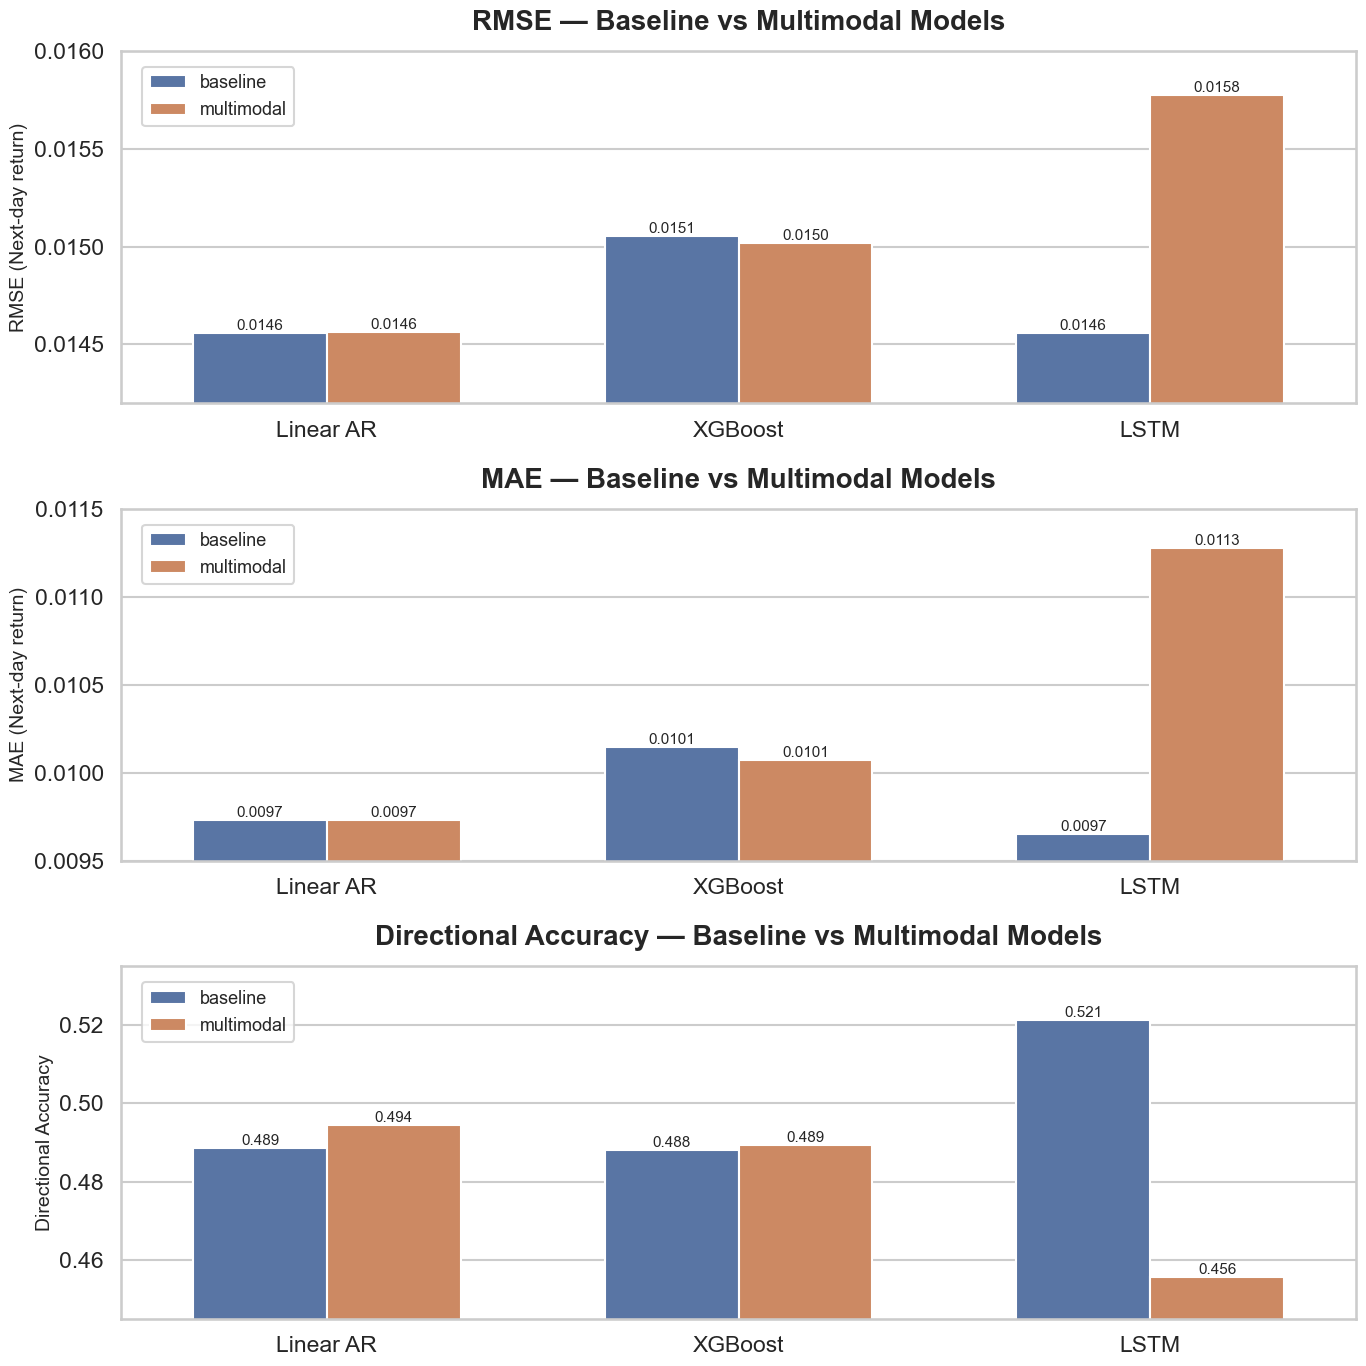

<Figure size 640x480 with 0 Axes>

In [19]:
palette = ["#4C72B0", "#DD8452"]   # blue, orange

plt.figure(figsize=(14, 14))  # Increased height to fit three plots

# Helper to be compatible with different seaborn versions
def barplot_no_errorbars(data, x, y, hue, palette, width):
    try:
        ax = sns.barplot(
            data=data, x=x, y=y, hue=hue,
            palette=palette, width=width,
            errorbar=None          # seaborn >= 0.12
        )
    except TypeError:
        ax = sns.barplot(
            data=data, x=x, y=y, hue=hue,
            palette=palette, width=width,
            ci=None                # seaborn < 0.12
        )
    return ax

# ------------------------------------------------------
# Reorder family for plotting: Linear AR, XGBoost, LSTM
# ------------------------------------------------------
family_order = ["Linear AR", "XGBoost", "LSTM"]
rmse_plot = rmse_plot.copy()
mae_plot = mae_plot.copy()
diracc_plot = diracc_plot.copy()
rmse_plot["family"] = pd.Categorical(rmse_plot["family"], categories=family_order, ordered=True)
mae_plot["family"] = pd.Categorical(mae_plot["family"], categories=family_order, ordered=True)
diracc_plot["family"] = pd.Categorical(diracc_plot["family"], categories=family_order, ordered=True)

# ------------------------------------------------------
# Add: Prepare data for MAE plot (long format)
# ------------------------------------------------------
# (already done above; moved below reorder for clarity)

# ------------------------------------------------------
# 1) RMSE Plot
# ------------------------------------------------------
plt.subplot(3, 1, 1)
ax1 = barplot_no_errorbars(
    data=rmse_plot.sort_values("family"),     # ensure correct order
    x="family", y="RMSE",
    hue="type", palette=palette, width=0.65
)

plt.title("RMSE — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("RMSE (Next-day return)", fontsize=14)

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f"{height:.4f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(
    title="",
    fontsize=13,
    loc="upper left",          # Changed from upper right to upper left (top left)
    bbox_to_anchor=(0.01, 0.98)  # Move precisely to top left (x=left margin, y=top)
)
plt.ylim(0.0142, 0.0160)

# ------------------------------------------------------
# 2) MAE Plot
# ------------------------------------------------------
plt.subplot(3, 1, 2)
ax_mae = barplot_no_errorbars(
    data=mae_plot.sort_values("family"),
    x="family", y="MAE",
    hue="type", palette=palette, width=0.65
)

plt.title("MAE — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("MAE (Next-day return)", fontsize=14)

for p in ax_mae.patches:
    height = p.get_height()
    ax_mae.annotate(
        f"{height:.4f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(
    title="",
    fontsize=13,
    loc="upper left",           # Changed from upper right to upper left
    bbox_to_anchor=(0.01, 0.98)
)
plt.ylim(0.0095, 0.0115)

# ------------------------------------------------------
# 3) Directional Accuracy Plot
# ------------------------------------------------------
plt.subplot(3, 1, 3)
ax2 = barplot_no_errorbars(
    data=diracc_plot.sort_values("family"),
    x="family", y="DirAcc",
    hue="type", palette=palette, width=0.65
)

plt.title("Directional Accuracy — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Directional Accuracy", fontsize=14)

for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f"{height:.3f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(
    title="",
    fontsize=13,
    loc="upper left",          # Changed from upper right to upper left
    bbox_to_anchor=(0.01, 0.98)
)
plt.ylim(0.445, 0.535)

plt.tight_layout()
plt.show()

# (optional) save
plt.savefig("../../figures/rmse_mae_diracc_comparison.png", dpi=300, bbox_inches="tight")


In [9]:
BASE_DIR

WindowsPath('C:/Users/mkcak/OneDrive - Hochschule Luzern/Modules/master_thesis/multimodal-finance-forecasting/code')

### Cap-level and Sector-level Performance Plots (Hard Numbers)


In [10]:
# Cap-level metrics data (hard numbers from notebook outputs)
cap_data = {
    "Linear AR": {
        "Large Cap": {"RMSE_base": 0.014967, "RMSE_mm": 0.014974, "DirAcc_base": 0.50000, "DirAcc_mm": 0.498},
        "Mid Cap": {"RMSE_base": 0.013797, "RMSE_mm": 0.013799, "DirAcc_base": 0.48800, "DirAcc_mm": 0.474},
        "Small Cap": {"RMSE_base": 0.014551, "RMSE_mm": 0.014552, "DirAcc_base": 0.48575, "DirAcc_mm": 0.496}
    },
    "XGBoost": {
        "Large Cap": {"RMSE_base": 0.015447, "RMSE_mm": 0.015281, "DirAcc_base": 0.5050, "DirAcc_mm": 0.4880},
        "Mid Cap": {"RMSE_base": 0.014168, "RMSE_mm": 0.014023, "DirAcc_base": 0.4840, "DirAcc_mm": 0.4920},
        "Small Cap": {"RMSE_base": 0.015065, "RMSE_mm": 0.015074, "DirAcc_base": 0.4845, "DirAcc_mm": 0.4895}
    },
    "LSTM": {
        "Large Cap": {"RMSE_base": 0.015042, "RMSE_mm": 0.016281, "DirAcc_base": 0.538298, "DirAcc_mm": 0.452128},
        "Mid Cap": {"RMSE_base": 0.013684, "RMSE_mm": 0.015629, "DirAcc_base": 0.546809, "DirAcc_mm": 0.429787},
        "Small Cap": {"RMSE_base": 0.014540, "RMSE_mm": 0.015661, "DirAcc_base": 0.513830, "DirAcc_mm": 0.459574}
    }
}

# Sector-level metrics data (hard numbers from notebook outputs)
sector_data = {
    "Linear AR": {
        "Health Care": {"RMSE_base": 0.020819, "RMSE_mm": 0.020822, "DirAcc_base": 0.494000, "DirAcc_mm": 0.516000},
        "Insurance": {"RMSE_base": 0.011585, "RMSE_mm": 0.011592, "DirAcc_base": 0.501000, "DirAcc_mm": 0.508000},
        "Consumer Staples": {"RMSE_base": 0.009838, "RMSE_mm": 0.009836, "DirAcc_base": 0.506000, "DirAcc_mm": 0.500000},
        "Banking": {"RMSE_base": 0.016020, "RMSE_mm": 0.016021, "DirAcc_base": 0.488667, "DirAcc_mm": 0.494667},
        "Consumer Discretionary": {"RMSE_base": 0.017408, "RMSE_mm": 0.017412, "DirAcc_base": 0.488000, "DirAcc_mm": 0.492000},
        "Real Estate - Energy - Industrials": {"RMSE_base": 0.013979, "RMSE_mm": 0.013981, "DirAcc_base": 0.484000, "DirAcc_mm": 0.482000},
        "Technology": {"RMSE_base": 0.008349, "RMSE_mm": 0.008348, "DirAcc_base": 0.450000, "DirAcc_mm": 0.466000}
    },
    "XGBoost": {
        "Consumer Staples": {"RMSE_base": 0.010036, "RMSE_mm": 0.009997, "DirAcc_base": 0.500, "DirAcc_mm": 0.508},
        "Insurance": {"RMSE_base": 0.011919, "RMSE_mm": 0.011806, "DirAcc_base": 0.489, "DirAcc_mm": 0.498},
        "Health Care": {"RMSE_base": 0.021755, "RMSE_mm": 0.022329, "DirAcc_base": 0.508, "DirAcc_mm": 0.496},
        "Banking": {"RMSE_base": 0.016481, "RMSE_mm": 0.016357, "DirAcc_base": 0.492, "DirAcc_mm": 0.492},
        "Consumer Discretionary": {"RMSE_base": 0.018067, "RMSE_mm": 0.017811, "DirAcc_base": 0.442, "DirAcc_mm": 0.490},
        "Real Estate - Energy - Industrials": {"RMSE_base": 0.014428, "RMSE_mm": 0.014322, "DirAcc_base": 0.493, "DirAcc_mm": 0.479},
        "Technology": {"RMSE_base": 0.008821, "RMSE_mm": 0.008610, "DirAcc_base": 0.480, "DirAcc_mm": 0.460}
    },
    "LSTM": {
        "Consumer Discretionary": {"RMSE_base": 0.017441, "RMSE_mm": 0.018002, "DirAcc_base": 0.465957, "DirAcc_mm": 0.519149},
        "Consumer Staples": {"RMSE_base": 0.009821, "RMSE_mm": 0.010759, "DirAcc_base": 0.474468, "DirAcc_mm": 0.512766},
        "Health Care": {"RMSE_base": 0.020784, "RMSE_mm": 0.021393, "DirAcc_base": 0.519149, "DirAcc_mm": 0.495745},
        "Technology": {"RMSE_base": 0.008148, "RMSE_mm": 0.009452, "DirAcc_base": 0.512766, "DirAcc_mm": 0.455319},
        "Banking": {"RMSE_base": 0.016087, "RMSE_mm": 0.017379, "DirAcc_base": 0.522695, "DirAcc_mm": 0.443972},
        "Real Estate - Energy - Industrials": {"RMSE_base": 0.013880, "RMSE_mm": 0.015634, "DirAcc_base": 0.540426, "DirAcc_mm": 0.436170},
        "Insurance": {"RMSE_base": 0.011628, "RMSE_mm": 0.013316, "DirAcc_base": 0.556383, "DirAcc_mm": 0.411702}
    }
}

# Convert to DataFrames for easier plotting
cap_records = []
for model, caps in cap_data.items():
    for cap, metrics in caps.items():
        cap_records.append({
            "Model": model,
            "Cap": cap,
            "RMSE_base": metrics["RMSE_base"],
            "RMSE_mm": metrics["RMSE_mm"],
            "DirAcc_base": metrics["DirAcc_base"],
            "DirAcc_mm": metrics["DirAcc_mm"]
        })
cap_df = pd.DataFrame(cap_records)

sector_records = []
for model, sectors in sector_data.items():
    for sector, metrics in sectors.items():
        sector_records.append({
            "Model": model,
            "Sector": sector,
            "RMSE_base": metrics["RMSE_base"],
            "RMSE_mm": metrics["RMSE_mm"],
            "DirAcc_base": metrics["DirAcc_base"],
            "DirAcc_mm": metrics["DirAcc_mm"]
        })
sector_df = pd.DataFrame(sector_records)

print("Cap-level data shape:", cap_df.shape)
print("Sector-level data shape:", sector_df.shape)
cap_df.head()


Cap-level data shape: (9, 6)
Sector-level data shape: (21, 6)


,Model,Cap,RMSE_base,RMSE_mm,DirAcc_base,DirAcc_mm
0,Linear AR,Large Cap,0.014967,0.014974,0.50000,0.498
1,Linear AR,Mid Cap,0.013797,0.013799,0.48800,0.474
2,Linear AR,Small Cap,0.014551,0.014552,0.48575,0.496
3,XGBoost,Large Cap,0.015447,0.015281,0.50500,0.488
4,XGBoost,Mid Cap,0.014168,0.014023,0.48400,0.492


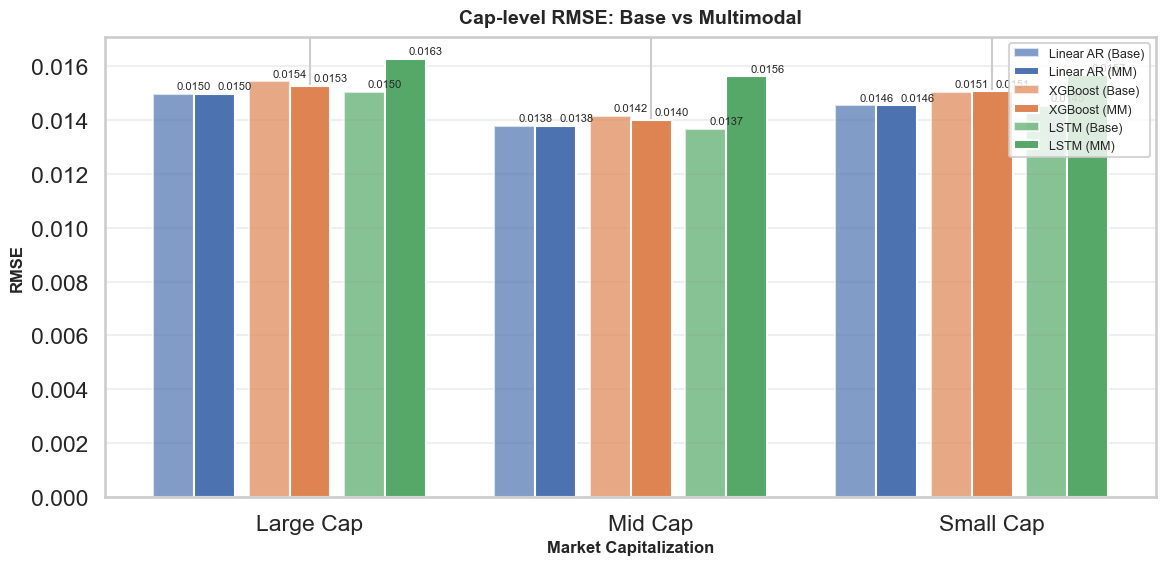

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\1_cap_level_rmse.png


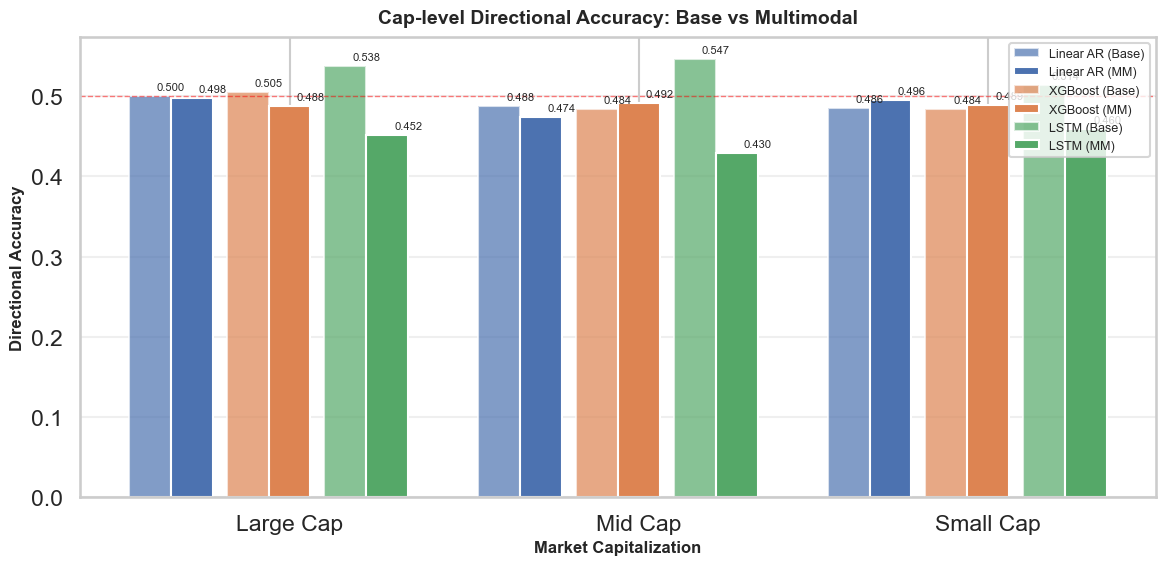

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\2_cap_level_diracc.png


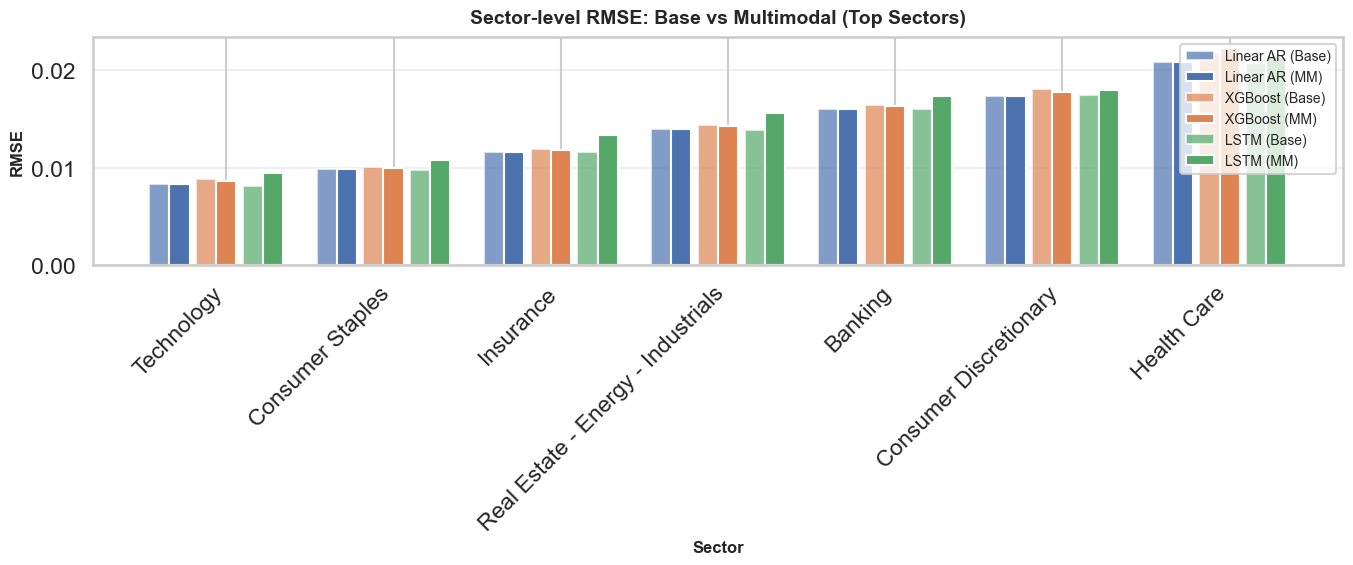

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\3_sector_level_rmse.png


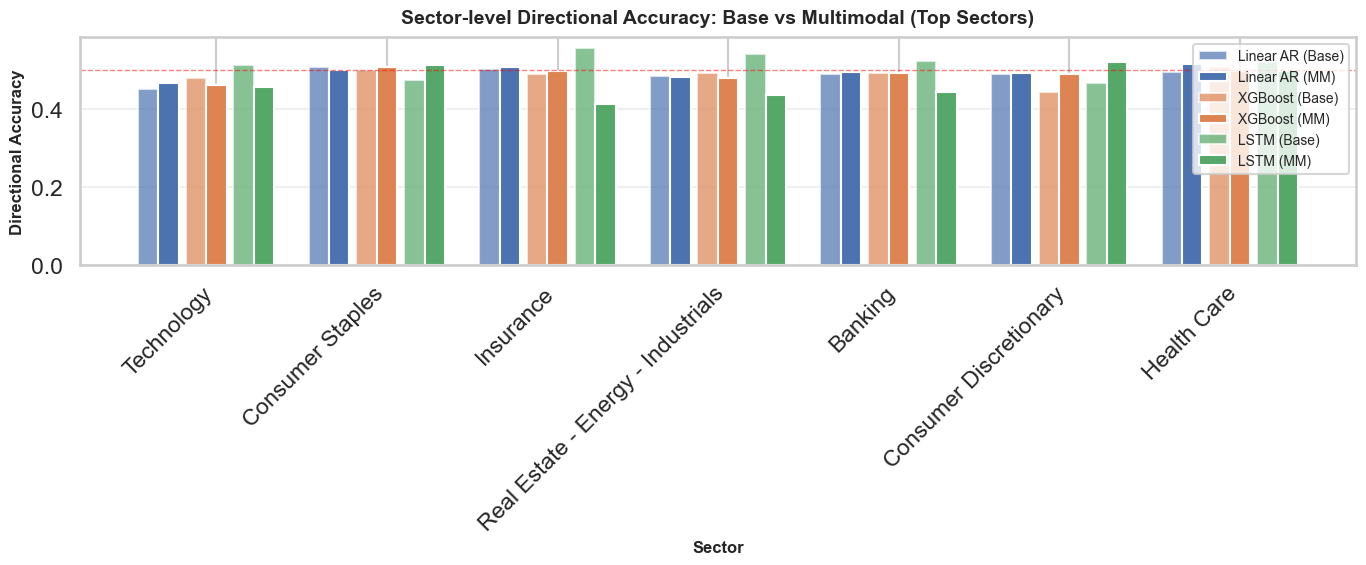

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\4_sector_level_diracc.png


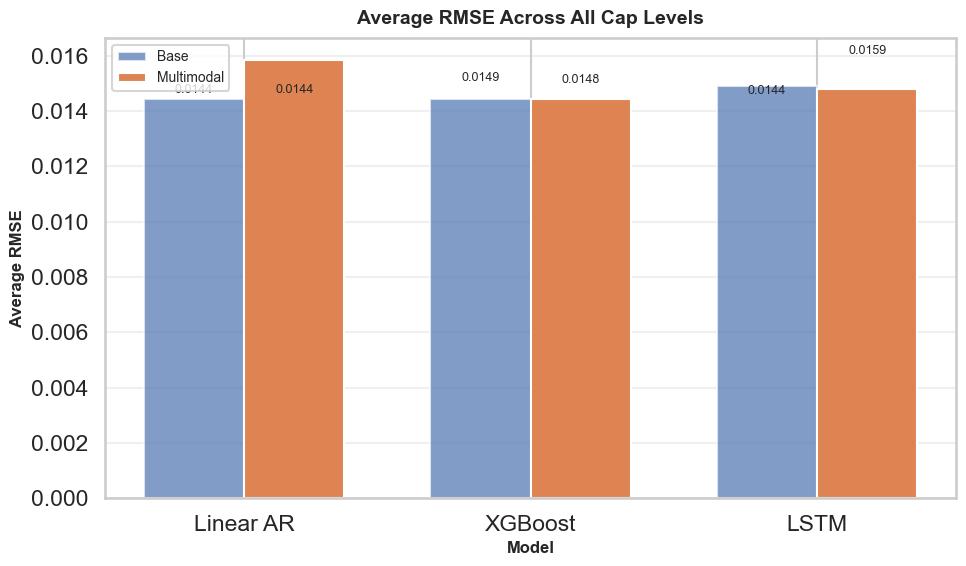

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\5_avg_rmse_all_caps.png


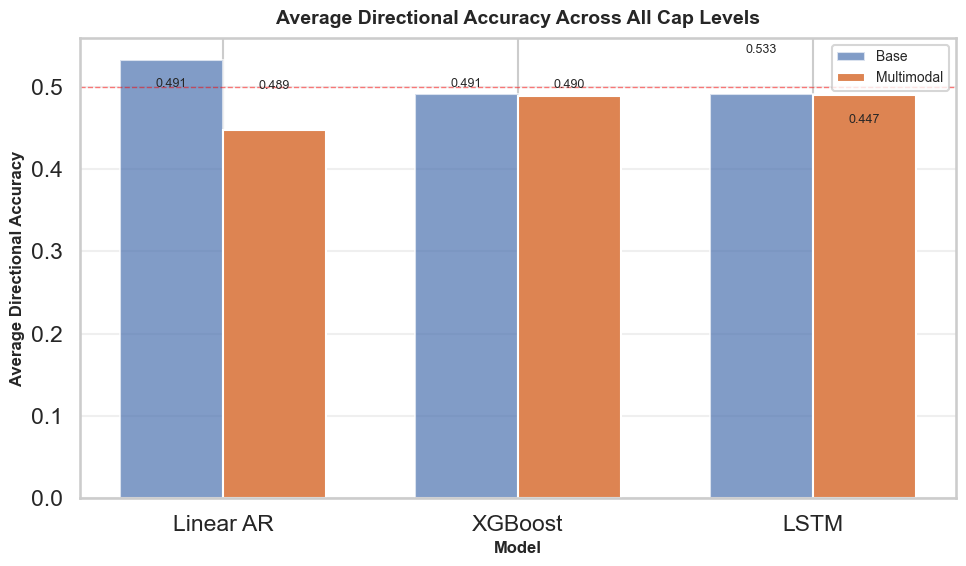

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\6_avg_diracc_all_caps.png

All plots saved to: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures


In [11]:
# Create separate plots for each visualization
# Color palette
palette_models = {"Linear AR": "#4C72B0", "XGBoost": "#DD8452", "LSTM": "#55A868"}
palette_type = {"Base": "#4C72B0", "Multimodal": "#DD8452"}

# Setup figures directory
figures_dir = BASE_DIR.parent / "figures"
figures_dir.mkdir(exist_ok=True)

# ============================================
# 1. Cap-level RMSE Comparison
# ============================================
fig1, ax1 = plt.subplots(figsize=(12, 6))
cap_rmse_long = pd.melt(
    cap_df,
    id_vars=["Model", "Cap"],
    value_vars=["RMSE_base", "RMSE_mm"],
    var_name="Type",
    value_name="RMSE"
)
cap_rmse_long["Type"] = cap_rmse_long["Type"].map({"RMSE_base": "Base", "RMSE_mm": "Multimodal"})

x_pos = np.arange(len(cap_df["Cap"].unique()))
bar_width = 0.12  # Width of each individual bar (Base or MM)
group_width = 0.8  # Total width for all 3 models per cap category
models = cap_df["Model"].unique()
caps = sorted(cap_df["Cap"].unique(), key=lambda x: ["Large Cap", "Mid Cap", "Small Cap"].index(x))

# Calculate spacing: (group_width - 3*2*bar_width) / 2 gives space between model groups
spacing = (group_width - len(models) * 2 * bar_width) / (len(models) - 1) if len(models) > 1 else 0

for i, model in enumerate(models):
    model_data = cap_rmse_long[cap_rmse_long["Model"] == model]
    base_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["RMSE"].values[0] 
                 for cap in caps]
    mm_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["RMSE"].values[0] 
               for cap in caps]
    
    # Position for this model: start from left edge of group, then offset by model index
    offset = i * (2 * bar_width + spacing)
    x = x_pos - group_width/2 + offset + bar_width
    
    ax1.bar(x - bar_width, base_vals, bar_width, label=f"{model} (Base)", color=palette_models[model], alpha=0.7)
    ax1.bar(x, mm_vals, bar_width, label=f"{model} (MM)", color=palette_models[model], alpha=1.0)

ax1.set_xlabel("Market Capitalization", fontsize=12, weight="bold")
ax1.set_ylabel("RMSE", fontsize=12, weight="bold")
ax1.set_title("Cap-level RMSE: Base vs Multimodal", fontsize=14, weight="bold", pad=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(caps)
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# Add value labels
for i, model in enumerate(models):
    model_data = cap_rmse_long[cap_rmse_long["Model"] == model]
    for j, cap in enumerate(caps):
        base_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["RMSE"].values[0]
        mm_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["RMSE"].values[0]
        offset = i * (2 * bar_width + spacing)
        x = j - group_width/2 + offset + bar_width
        ax1.text(x - bar_width/2, base_val + 0.0001, f"{base_val:.4f}", ha="center", va="bottom", fontsize=8)
        ax1.text(x + bar_width/2, mm_val + 0.0001, f"{mm_val:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "1_cap_level_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '1_cap_level_rmse.png'}")

# ============================================
# 2. Cap-level Directional Accuracy Comparison
# ============================================
fig2, ax2 = plt.subplots(figsize=(12, 6))
cap_diracc_long = pd.melt(
    cap_df,
    id_vars=["Model", "Cap"],
    value_vars=["DirAcc_base", "DirAcc_mm"],
    var_name="Type",
    value_name="DirAcc"
)
cap_diracc_long["Type"] = cap_diracc_long["Type"].map({"DirAcc_base": "Base", "DirAcc_mm": "Multimodal"})

for i, model in enumerate(models):
    model_data = cap_diracc_long[cap_diracc_long["Model"] == model]
    base_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["DirAcc"].values[0] 
                 for cap in caps]
    mm_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["DirAcc"].values[0] 
               for cap in caps]
    
    offset = i * (2 * bar_width + spacing)
    x = x_pos - group_width/2 + offset + bar_width
    
    ax2.bar(x - bar_width, base_vals, bar_width, label=f"{model} (Base)", color=palette_models[model], alpha=0.7)
    ax2.bar(x, mm_vals, bar_width, label=f"{model} (MM)", color=palette_models[model], alpha=1.0)

ax2.set_xlabel("Market Capitalization", fontsize=12, weight="bold")
ax2.set_ylabel("Directional Accuracy", fontsize=12, weight="bold")
ax2.set_title("Cap-level Directional Accuracy: Base vs Multimodal", fontsize=14, weight="bold", pad=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(caps)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, linewidth=1, label="Random (0.5)")

# Add value labels
for i, model in enumerate(models):
    model_data = cap_diracc_long[cap_diracc_long["Model"] == model]
    for j, cap in enumerate(caps):
        base_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["DirAcc"].values[0]
        mm_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["DirAcc"].values[0]
        offset = i * (2 * bar_width + spacing)
        x = j - group_width/2 + offset + bar_width
        ax2.text(x - bar_width/2, base_val + 0.005, f"{base_val:.3f}", ha="center", va="bottom", fontsize=8)
        ax2.text(x + bar_width/2, mm_val + 0.005, f"{mm_val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "2_cap_level_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '2_cap_level_diracc.png'}")

# ============================================
# 3. Sector-level RMSE Comparison (Top 6 sectors by average performance)
# ============================================
fig3, ax3 = plt.subplots(figsize=(14, 6))
# Get sectors that appear in all models or most models
all_sectors = set()
for model in sector_data.keys():
    all_sectors.update(sector_data[model].keys())

# Calculate average RMSE_mm for each sector across models
sector_avg_rmse = {}
for sector in all_sectors:
    rmses = []
    for model in sector_data.keys():
        if sector in sector_data[model]:
            rmses.append(sector_data[model][sector]["RMSE_mm"])
    if rmses:
        sector_avg_rmse[sector] = np.mean(rmses)

# Get top sectors by average RMSE (lowest is best)
# Include Technology which has very low RMSE, so we'll take top 7 to ensure it's included
top_sectors = sorted(sector_avg_rmse.items(), key=lambda x: x[1])[:7]
top_sector_names = [s[0] for s in top_sectors]

sector_rmse_long = pd.melt(
    sector_df[sector_df["Sector"].isin(top_sector_names)],
    id_vars=["Model", "Sector"],
    value_vars=["RMSE_base", "RMSE_mm"],
    var_name="Type",
    value_name="RMSE"
)
sector_rmse_long["Type"] = sector_rmse_long["Type"].map({"RMSE_base": "Base", "RMSE_mm": "Multimodal"})

x_pos_sector = np.arange(len(top_sector_names))
bar_width_sector = 0.12
group_width_sector = 0.8
spacing_sector = (group_width_sector - len(models) * 2 * bar_width_sector) / (len(models) - 1) if len(models) > 1 else 0

for i, model in enumerate(models):
    model_data = sector_rmse_long[sector_rmse_long["Model"] == model]
    base_vals = []
    mm_vals = []
    for sector in top_sector_names:
        sector_model_data = model_data[model_data["Sector"] == sector]
        if len(sector_model_data) > 0:
            base_vals.append(sector_model_data[sector_model_data["Type"] == "Base"]["RMSE"].values[0])
            mm_vals.append(sector_model_data[sector_model_data["Type"] == "Multimodal"]["RMSE"].values[0])
        else:
            base_vals.append(np.nan)
            mm_vals.append(np.nan)
    
    offset = i * (2 * bar_width_sector + spacing_sector)
    x = x_pos_sector - group_width_sector/2 + offset + bar_width_sector
    
    ax3.bar(x - bar_width_sector, base_vals, bar_width_sector, label=f"{model} (Base)", 
            color=palette_models[model], alpha=0.7)
    ax3.bar(x, mm_vals, bar_width_sector, label=f"{model} (MM)", 
            color=palette_models[model], alpha=1.0)

ax3.set_xlabel("Sector", fontsize=12, weight="bold")
ax3.set_ylabel("RMSE", fontsize=12, weight="bold")
ax3.set_title("Sector-level RMSE: Base vs Multimodal (Top Sectors)", fontsize=14, weight="bold", pad=10)
ax3.set_xticks(x_pos_sector)
ax3.set_xticklabels(top_sector_names, rotation=45, ha="right")
ax3.legend(loc="upper right", fontsize=10)
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "3_sector_level_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '3_sector_level_rmse.png'}")

# ============================================
# 4. Sector-level Directional Accuracy Comparison
# ============================================
fig4, ax4 = plt.subplots(figsize=(14, 6))
sector_diracc_long = pd.melt(
    sector_df[sector_df["Sector"].isin(top_sector_names)],
    id_vars=["Model", "Sector"],
    value_vars=["DirAcc_base", "DirAcc_mm"],
    var_name="Type",
    value_name="DirAcc"
)
sector_diracc_long["Type"] = sector_diracc_long["Type"].map({"DirAcc_base": "Base", "DirAcc_mm": "Multimodal"})

for i, model in enumerate(models):
    model_data = sector_diracc_long[sector_diracc_long["Model"] == model]
    base_vals = []
    mm_vals = []
    for sector in top_sector_names:
        sector_model_data = model_data[model_data["Sector"] == sector]
        if len(sector_model_data) > 0:
            base_vals.append(sector_model_data[sector_model_data["Type"] == "Base"]["DirAcc"].values[0])
            mm_vals.append(sector_model_data[sector_model_data["Type"] == "Multimodal"]["DirAcc"].values[0])
        else:
            base_vals.append(np.nan)
            mm_vals.append(np.nan)
    
    offset = i * (2 * bar_width_sector + spacing_sector)
    x = x_pos_sector - group_width_sector/2 + offset + bar_width_sector
    
    ax4.bar(x - bar_width_sector, base_vals, bar_width_sector, label=f"{model} (Base)", 
            color=palette_models[model], alpha=0.7)
    ax4.bar(x, mm_vals, bar_width_sector, label=f"{model} (MM)", 
            color=palette_models[model], alpha=1.0)

ax4.set_xlabel("Sector", fontsize=12, weight="bold")
ax4.set_ylabel("Directional Accuracy", fontsize=12, weight="bold")
ax4.set_title("Sector-level Directional Accuracy: Base vs Multimodal (Top Sectors)", fontsize=14, weight="bold", pad=10)
ax4.set_xticks(x_pos_sector)
ax4.set_xticklabels(top_sector_names, rotation=45, ha="right")
ax4.legend(loc="upper right", fontsize=10)
ax4.grid(axis="y", alpha=0.3)
ax4.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, linewidth=1, label="Random (0.5)")

plt.tight_layout()
plt.savefig(figures_dir / "4_sector_level_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '4_sector_level_diracc.png'}")

# ============================================
# 5. Model Comparison: Average RMSE across all caps
# ============================================
fig5, ax5 = plt.subplots(figsize=(10, 6))
avg_rmse = cap_df.groupby("Model")[["RMSE_base", "RMSE_mm"]].mean()
x_pos_models = np.arange(len(models))
width_avg = 0.35

ax5.bar(x_pos_models - width_avg/2, avg_rmse["RMSE_base"], width_avg, 
        label="Base", color="#4C72B0", alpha=0.7)
ax5.bar(x_pos_models + width_avg/2, avg_rmse["RMSE_mm"], width_avg, 
        label="Multimodal", color="#DD8452", alpha=1.0)

ax5.set_xlabel("Model", fontsize=12, weight="bold")
ax5.set_ylabel("Average RMSE", fontsize=12, weight="bold")
ax5.set_title("Average RMSE Across All Cap Levels", fontsize=14, weight="bold", pad=10)
ax5.set_xticks(x_pos_models)
ax5.set_xticklabels(models)
ax5.legend(fontsize=10)
ax5.grid(axis="y", alpha=0.3)

# Add value labels
for i, model in enumerate(models):
    base_val = avg_rmse.loc[model, "RMSE_base"]
    mm_val = avg_rmse.loc[model, "RMSE_mm"]
    ax5.text(i - width_avg/2, base_val + 0.0001, f"{base_val:.4f}", 
             ha="center", va="bottom", fontsize=9)
    ax5.text(i + width_avg/2, mm_val + 0.0001, f"{mm_val:.4f}", 
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / "5_avg_rmse_all_caps.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '5_avg_rmse_all_caps.png'}")

# ============================================
# 6. Model Comparison: Average Directional Accuracy across all caps
# ============================================
fig6, ax6 = plt.subplots(figsize=(10, 6))
avg_diracc = cap_df.groupby("Model")[["DirAcc_base", "DirAcc_mm"]].mean()
x_pos_models = np.arange(len(models))
width_avg = 0.35

ax6.bar(x_pos_models - width_avg/2, avg_diracc["DirAcc_base"], width_avg, 
        label="Base", color="#4C72B0", alpha=0.7)
ax6.bar(x_pos_models + width_avg/2, avg_diracc["DirAcc_mm"], width_avg, 
        label="Multimodal", color="#DD8452", alpha=1.0)

ax6.set_xlabel("Model", fontsize=12, weight="bold")
ax6.set_ylabel("Average Directional Accuracy", fontsize=12, weight="bold")
ax6.set_title("Average Directional Accuracy Across All Cap Levels", fontsize=14, weight="bold", pad=10)
ax6.set_xticks(x_pos_models)
ax6.set_xticklabels(models)
ax6.legend(fontsize=10)
ax6.grid(axis="y", alpha=0.3)
ax6.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, linewidth=1, label="Random (0.5)")

# Add value labels
for i, model in enumerate(models):
    base_val = avg_diracc.loc[model, "DirAcc_base"]
    mm_val = avg_diracc.loc[model, "DirAcc_mm"]
    ax6.text(i - width_avg/2, base_val + 0.005, f"{base_val:.3f}", 
             ha="center", va="bottom", fontsize=9)
    ax6.text(i + width_avg/2, mm_val + 0.005, f"{mm_val:.3f}", 
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / "6_avg_diracc_all_caps.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '6_avg_diracc_all_caps.png'}")

print(f"\nAll plots saved to: {figures_dir}")


### Alternative Representation: Grouped by Model (Base vs MM side-by-side)


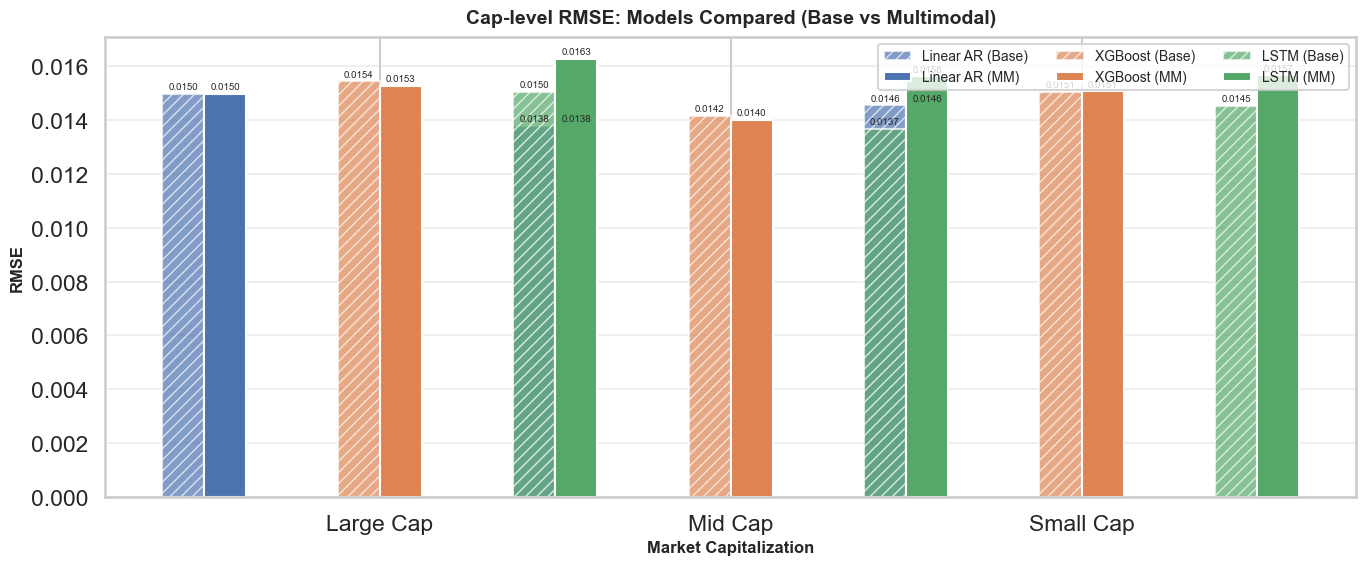

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\1_alt_cap_level_rmse.png


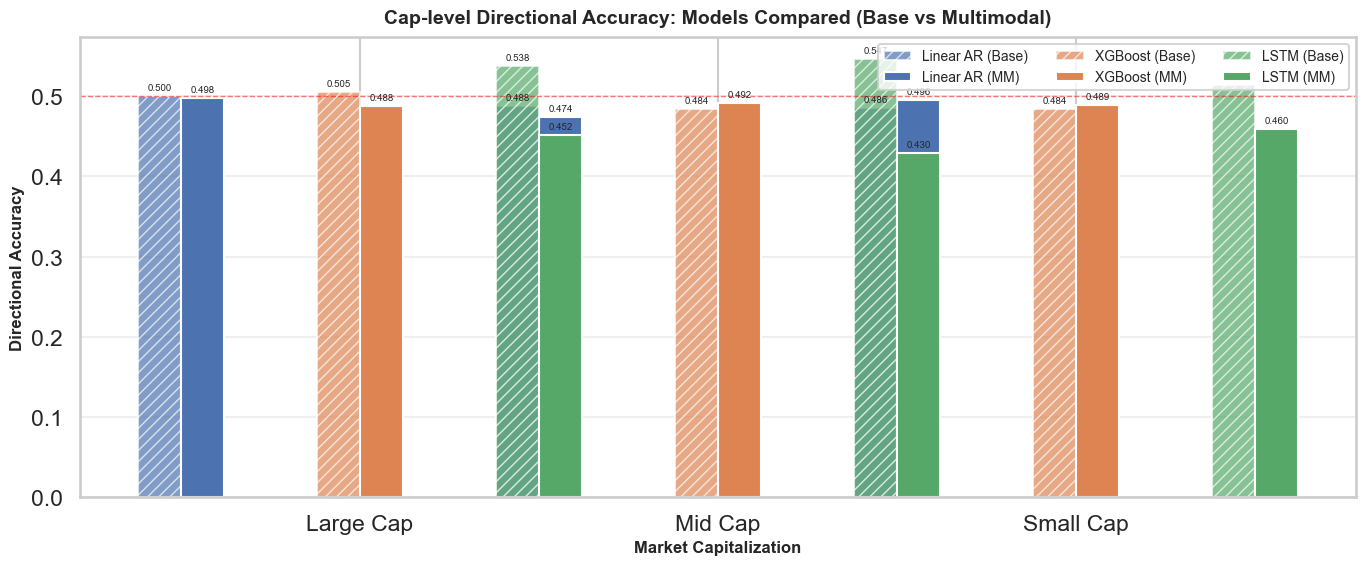

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\2_alt_cap_level_diracc.png


In [12]:
# Alternative 1: Grouped by Model - Base and MM side-by-side for each model
# This makes it easier to see the improvement of MM over Base for each model

# ============================================
# 1. Cap-level RMSE - Alternative Representation
# ============================================
fig1_alt, ax1_alt = plt.subplots(figsize=(14, 6))

# Prepare data: group by model, then show Base vs MM
x_pos_alt = np.arange(len(caps))
bar_width_alt = 0.12
group_width_alt = 0.35  # Width for each model's group (Base + MM + small gap)
spacing_alt = 0.15  # Space between model groups

for i, model in enumerate(models):
    model_data = cap_rmse_long[cap_rmse_long["Model"] == model]
    base_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["RMSE"].values[0] 
                 for cap in caps]
    mm_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["RMSE"].values[0] 
               for cap in caps]
    
    # Position for this model group
    x = x_pos_alt + i * (group_width_alt + spacing_alt)
    
    # Base bar (left) and MM bar (right) within the group
    ax1_alt.bar(x - bar_width_alt/2, base_vals, bar_width_alt, 
                label=f"{model} (Base)", color=palette_models[model], alpha=0.7, hatch='///')
    ax1_alt.bar(x + bar_width_alt/2, mm_vals, bar_width_alt, 
                label=f"{model} (MM)", color=palette_models[model], alpha=1.0)

# Set x-axis
ax1_alt.set_xlabel("Market Capitalization", fontsize=12, weight="bold")
ax1_alt.set_ylabel("RMSE", fontsize=12, weight="bold")
ax1_alt.set_title("Cap-level RMSE: Models Compared (Base vs Multimodal)", fontsize=14, weight="bold", pad=10)

# Set x-ticks at the center of each cap category (accounting for all model groups)
tick_positions = x_pos_alt + (len(models) - 1) * (group_width_alt + spacing_alt) / 2
ax1_alt.set_xticks(tick_positions)
ax1_alt.set_xticklabels(caps)
ax1_alt.legend(loc="upper right", fontsize=10, ncol=3)
ax1_alt.grid(axis="y", alpha=0.3)

# Add value labels
for i, model in enumerate(models):
    model_data = cap_rmse_long[cap_rmse_long["Model"] == model]
    for j, cap in enumerate(caps):
        base_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["RMSE"].values[0]
        mm_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["RMSE"].values[0]
        x = j + i * (group_width_alt + spacing_alt)
        ax1_alt.text(x - bar_width_alt/2, base_val + 0.0001, f"{base_val:.4f}", 
                     ha="center", va="bottom", fontsize=7)
        ax1_alt.text(x + bar_width_alt/2, mm_val + 0.0001, f"{mm_val:.4f}", 
                     ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(figures_dir / "1_alt_cap_level_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '1_alt_cap_level_rmse.png'}")

# ============================================
# 2. Cap-level Directional Accuracy - Alternative Representation
# ============================================
fig2_alt, ax2_alt = plt.subplots(figsize=(14, 6))

for i, model in enumerate(models):
    model_data = cap_diracc_long[cap_diracc_long["Model"] == model]
    base_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["DirAcc"].values[0] 
                 for cap in caps]
    mm_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["DirAcc"].values[0] 
               for cap in caps]
    
    x = x_pos_alt + i * (group_width_alt + spacing_alt)
    ax2_alt.bar(x - bar_width_alt/2, base_vals, bar_width_alt, 
                label=f"{model} (Base)", color=palette_models[model], alpha=0.7, hatch='///')
    ax2_alt.bar(x + bar_width_alt/2, mm_vals, bar_width_alt, 
                label=f"{model} (MM)", color=palette_models[model], alpha=1.0)

ax2_alt.set_xlabel("Market Capitalization", fontsize=12, weight="bold")
ax2_alt.set_ylabel("Directional Accuracy", fontsize=12, weight="bold")
ax2_alt.set_title("Cap-level Directional Accuracy: Models Compared (Base vs Multimodal)", fontsize=14, weight="bold", pad=10)
ax2_alt.set_xticks(tick_positions)
ax2_alt.set_xticklabels(caps)
ax2_alt.legend(loc="upper right", fontsize=10, ncol=3)
ax2_alt.grid(axis="y", alpha=0.3)
ax2_alt.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, linewidth=1, label="Random (0.5)")

# Add value labels
for i, model in enumerate(models):
    model_data = cap_diracc_long[cap_diracc_long["Model"] == model]
    for j, cap in enumerate(caps):
        base_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["DirAcc"].values[0]
        mm_val = model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["DirAcc"].values[0]
        x = j + i * (group_width_alt + spacing_alt)
        ax2_alt.text(x - bar_width_alt/2, base_val + 0.005, f"{base_val:.3f}", 
                     ha="center", va="bottom", fontsize=7)
        ax2_alt.text(x + bar_width_alt/2, mm_val + 0.005, f"{mm_val:.3f}", 
                     ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(figures_dir / "2_alt_cap_level_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '2_alt_cap_level_diracc.png'}")


### Alternative Representation 2: Separate Subplots for Each Model


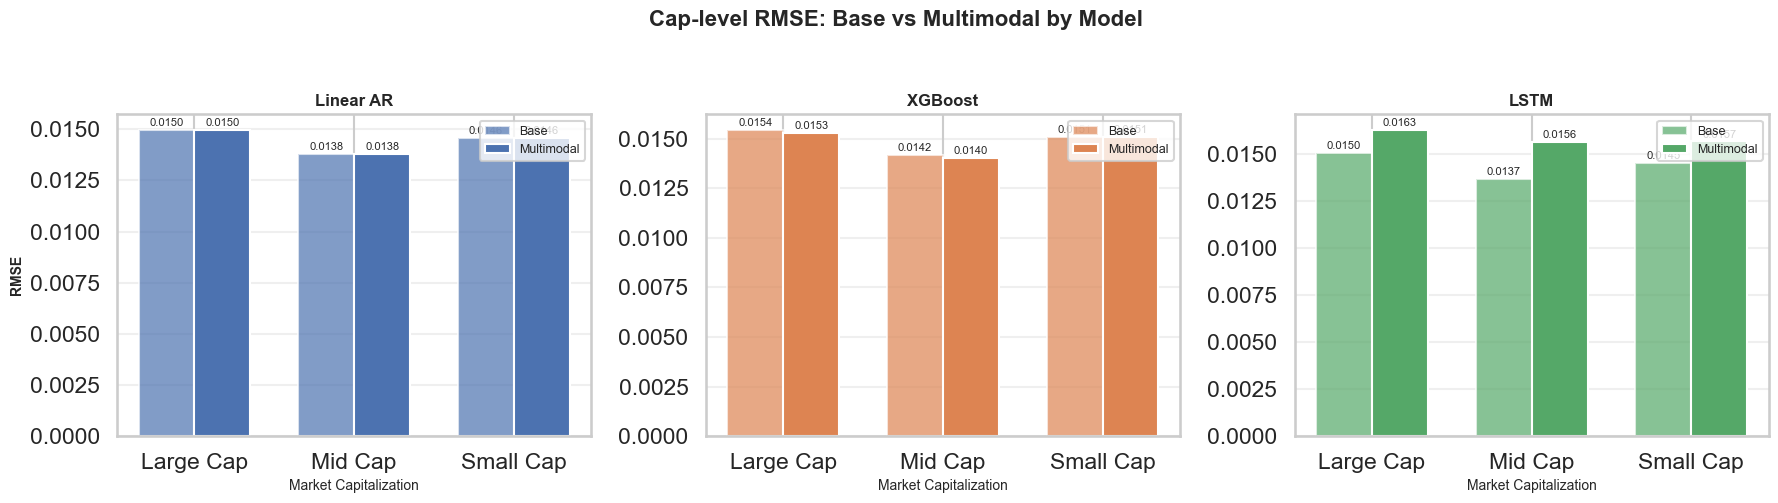

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\1_subplots_cap_level_rmse.png


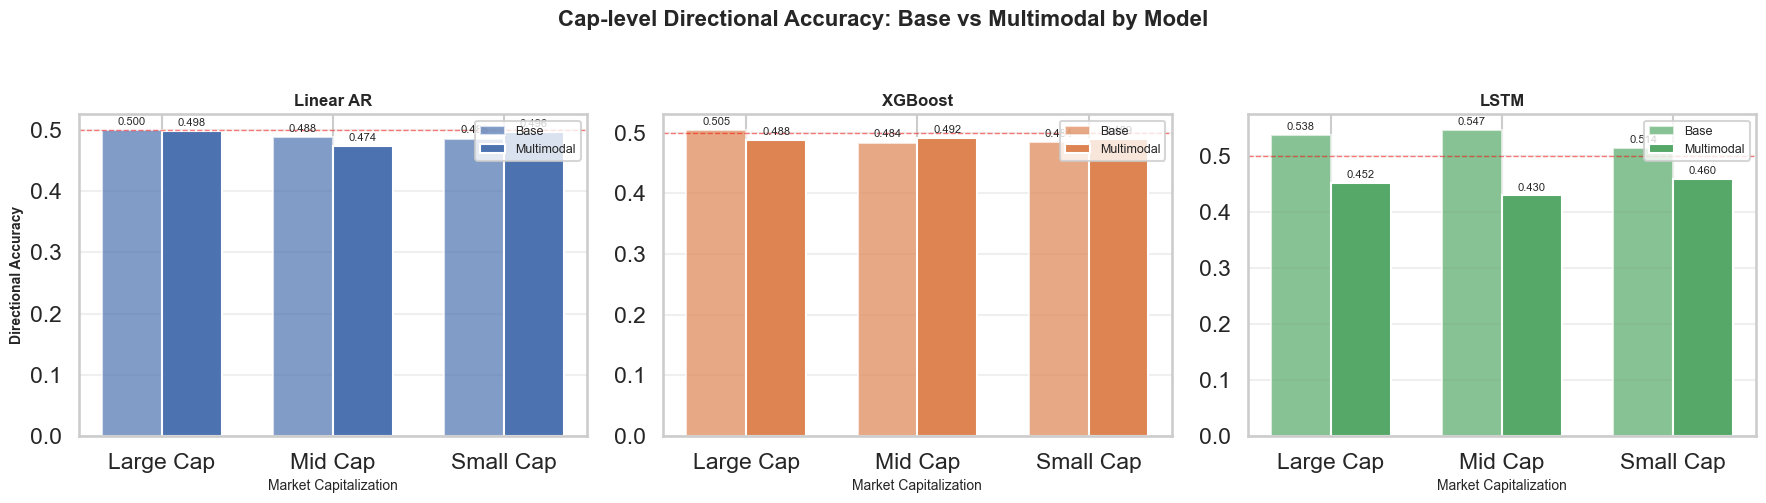

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\2_subplots_cap_level_diracc.png


In [13]:
# Alternative 2: Separate subplot for each model - easier to compare Base vs MM for each model individually

# ============================================
# Cap-level RMSE - Separate subplots per model
# ============================================
fig_sub1, axes_sub1 = plt.subplots(1, 3, figsize=(18, 5))
fig_sub1.suptitle("Cap-level RMSE: Base vs Multimodal by Model", fontsize=16, weight="bold", y=1.02)

x_pos_sub = np.arange(len(caps))
bar_width_sub = 0.35

for idx, model in enumerate(models):
    ax = axes_sub1[idx]
    model_data = cap_rmse_long[cap_rmse_long["Model"] == model]
    base_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["RMSE"].values[0] 
                 for cap in caps]
    mm_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["RMSE"].values[0] 
               for cap in caps]
    
    ax.bar(x_pos_sub - bar_width_sub/2, base_vals, bar_width_sub, 
           label="Base", color=palette_models[model], alpha=0.7)
    ax.bar(x_pos_sub + bar_width_sub/2, mm_vals, bar_width_sub, 
           label="Multimodal", color=palette_models[model], alpha=1.0)
    
    ax.set_title(model, fontsize=12, weight="bold")
    ax.set_xlabel("Market Capitalization", fontsize=10)
    if idx == 0:
        ax.set_ylabel("RMSE", fontsize=10, weight="bold")
    ax.set_xticks(x_pos_sub)
    ax.set_xticklabels(caps)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    
    # Add value labels
    for j, cap in enumerate(caps):
        ax.text(j - bar_width_sub/2, base_vals[j] + 0.0001, f"{base_vals[j]:.4f}", 
                ha="center", va="bottom", fontsize=8)
        ax.text(j + bar_width_sub/2, mm_vals[j] + 0.0001, f"{mm_vals[j]:.4f}", 
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "1_subplots_cap_level_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '1_subplots_cap_level_rmse.png'}")

# ============================================
# Cap-level Directional Accuracy - Separate subplots per model
# ============================================
fig_sub2, axes_sub2 = plt.subplots(1, 3, figsize=(18, 5))
fig_sub2.suptitle("Cap-level Directional Accuracy: Base vs Multimodal by Model", fontsize=16, weight="bold", y=1.02)

for idx, model in enumerate(models):
    ax = axes_sub2[idx]
    model_data = cap_diracc_long[cap_diracc_long["Model"] == model]
    base_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["DirAcc"].values[0] 
                 for cap in caps]
    mm_vals = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["DirAcc"].values[0] 
               for cap in caps]
    
    ax.bar(x_pos_sub - bar_width_sub/2, base_vals, bar_width_sub, 
           label="Base", color=palette_models[model], alpha=0.7)
    ax.bar(x_pos_sub + bar_width_sub/2, mm_vals, bar_width_sub, 
           label="Multimodal", color=palette_models[model], alpha=1.0)
    
    ax.set_title(model, fontsize=12, weight="bold")
    ax.set_xlabel("Market Capitalization", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Directional Accuracy", fontsize=10, weight="bold")
    ax.set_xticks(x_pos_sub)
    ax.set_xticklabels(caps)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, linewidth=1)
    
    # Add value labels
    for j, cap in enumerate(caps):
        ax.text(j - bar_width_sub/2, base_vals[j] + 0.005, f"{base_vals[j]:.3f}", 
                ha="center", va="bottom", fontsize=8)
        ax.text(j + bar_width_sub/2, mm_vals[j] + 0.005, f"{mm_vals[j]:.3f}", 
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "2_subplots_cap_level_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '2_subplots_cap_level_diracc.png'}")


### Alternative Representation 3: Heatmap View


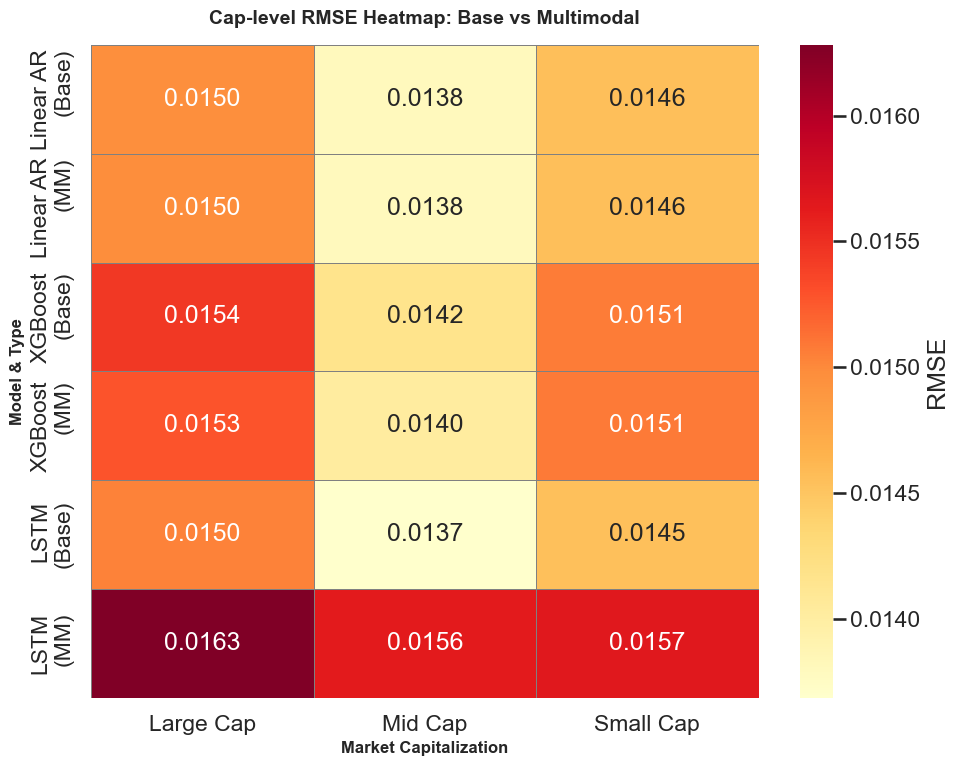

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\1_heatmap_cap_level_rmse.png


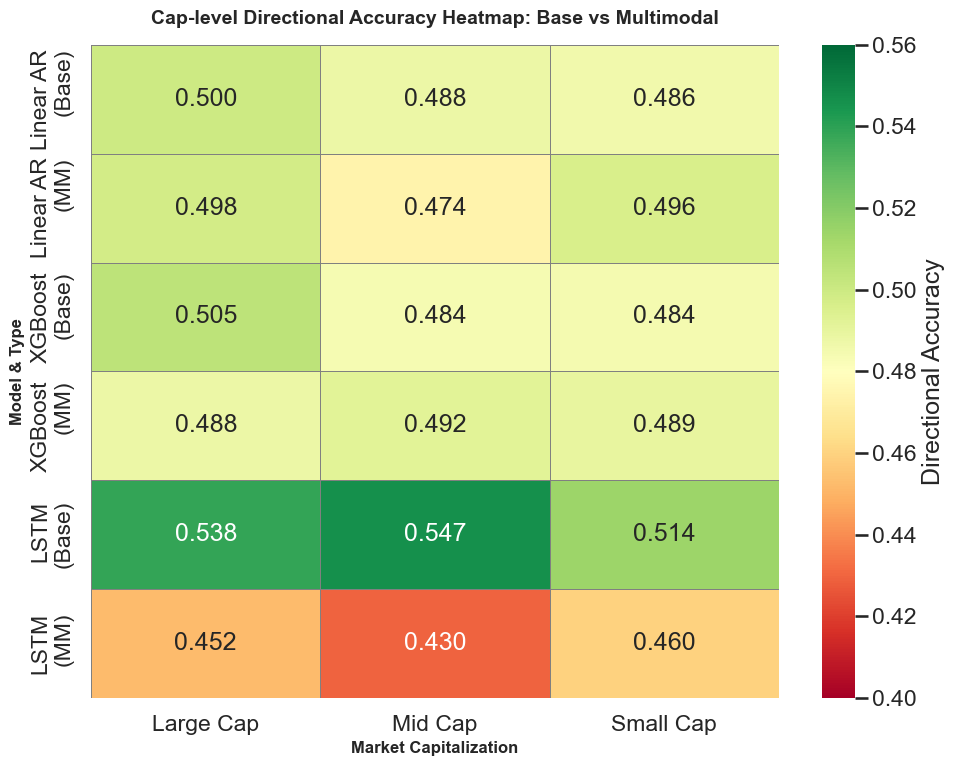

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\2_heatmap_cap_level_diracc.png

All alternative plots saved to: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures


In [14]:
# Alternative 3: Heatmap representation - shows patterns across models and caps

# ============================================
# Cap-level RMSE Heatmap
# ============================================
# Prepare data for heatmap
heatmap_data_rmse = []
heatmap_labels = []

for model in models:
    model_data = cap_rmse_long[cap_rmse_long["Model"] == model]
    base_row = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["RMSE"].values[0] 
                for cap in caps]
    mm_row = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["RMSE"].values[0] 
              for cap in caps]
    heatmap_data_rmse.append(base_row)
    heatmap_data_rmse.append(mm_row)
    heatmap_labels.append(f"{model}\n(Base)")
    heatmap_labels.append(f"{model}\n(MM)")

heatmap_df_rmse = pd.DataFrame(heatmap_data_rmse, index=heatmap_labels, columns=caps)

fig_heat1, ax_heat1 = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_df_rmse, annot=True, fmt=".4f", cmap="YlOrRd", 
            cbar_kws={"label": "RMSE"}, ax=ax_heat1, linewidths=0.5, linecolor="gray")
ax_heat1.set_title("Cap-level RMSE Heatmap: Base vs Multimodal", fontsize=14, weight="bold", pad=15)
ax_heat1.set_xlabel("Market Capitalization", fontsize=12, weight="bold")
ax_heat1.set_ylabel("Model & Type", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "1_heatmap_cap_level_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '1_heatmap_cap_level_rmse.png'}")

# ============================================
# Cap-level Directional Accuracy Heatmap
# ============================================
heatmap_data_diracc = []
for model in models:
    model_data = cap_diracc_long[cap_diracc_long["Model"] == model]
    base_row = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Base")]["DirAcc"].values[0] 
                for cap in caps]
    mm_row = [model_data[(model_data["Cap"] == cap) & (model_data["Type"] == "Multimodal")]["DirAcc"].values[0] 
              for cap in caps]
    heatmap_data_diracc.append(base_row)
    heatmap_data_diracc.append(mm_row)

heatmap_df_diracc = pd.DataFrame(heatmap_data_diracc, index=heatmap_labels, columns=caps)

fig_heat2, ax_heat2 = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_df_diracc, annot=True, fmt=".3f", cmap="RdYlGn", 
            cbar_kws={"label": "Directional Accuracy"}, ax=ax_heat2, 
            linewidths=0.5, linecolor="gray", vmin=0.4, vmax=0.56)
ax_heat2.set_title("Cap-level Directional Accuracy Heatmap: Base vs Multimodal", fontsize=14, weight="bold", pad=15)
ax_heat2.set_xlabel("Market Capitalization", fontsize=12, weight="bold")
ax_heat2.set_ylabel("Model & Type", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "2_heatmap_cap_level_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '2_heatmap_cap_level_diracc.png'}")

print(f"\nAll alternative plots saved to: {figures_dir}")


### Sector-level Heatmaps


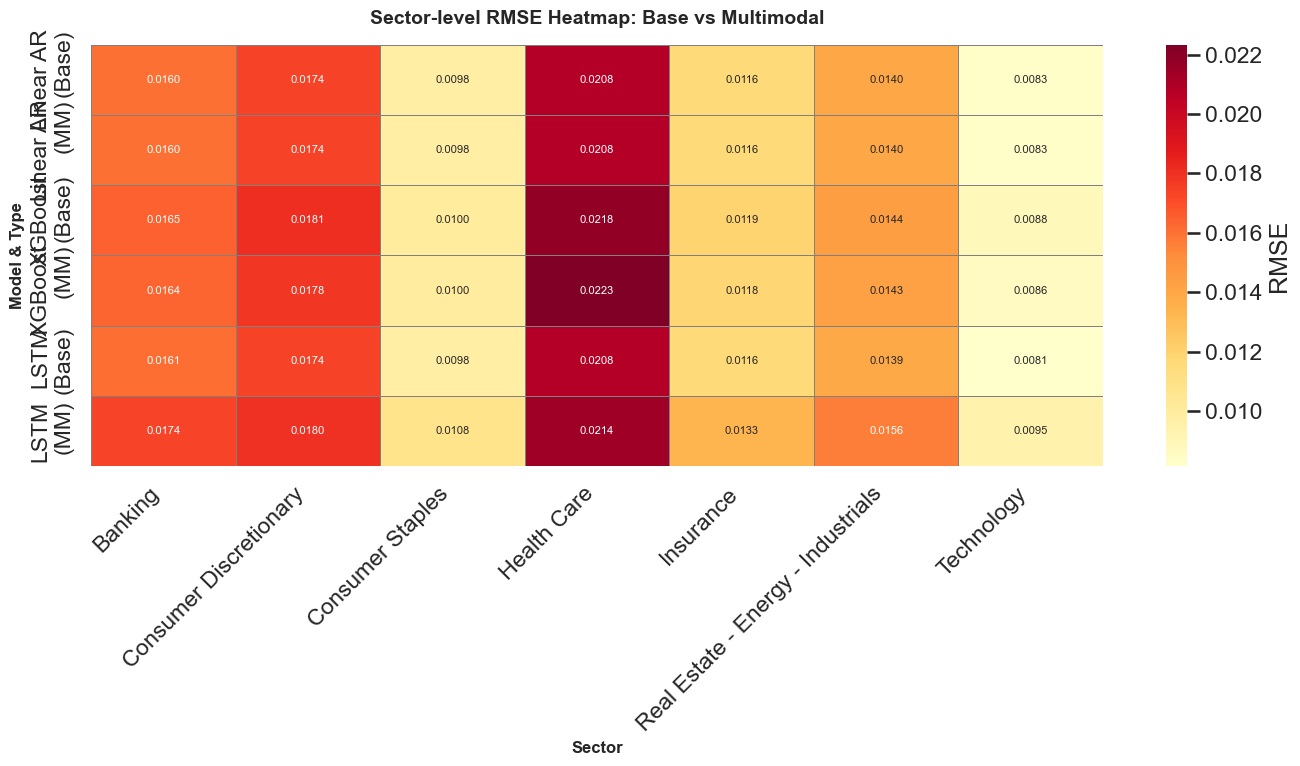

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\3_heatmap_sector_level_rmse.png


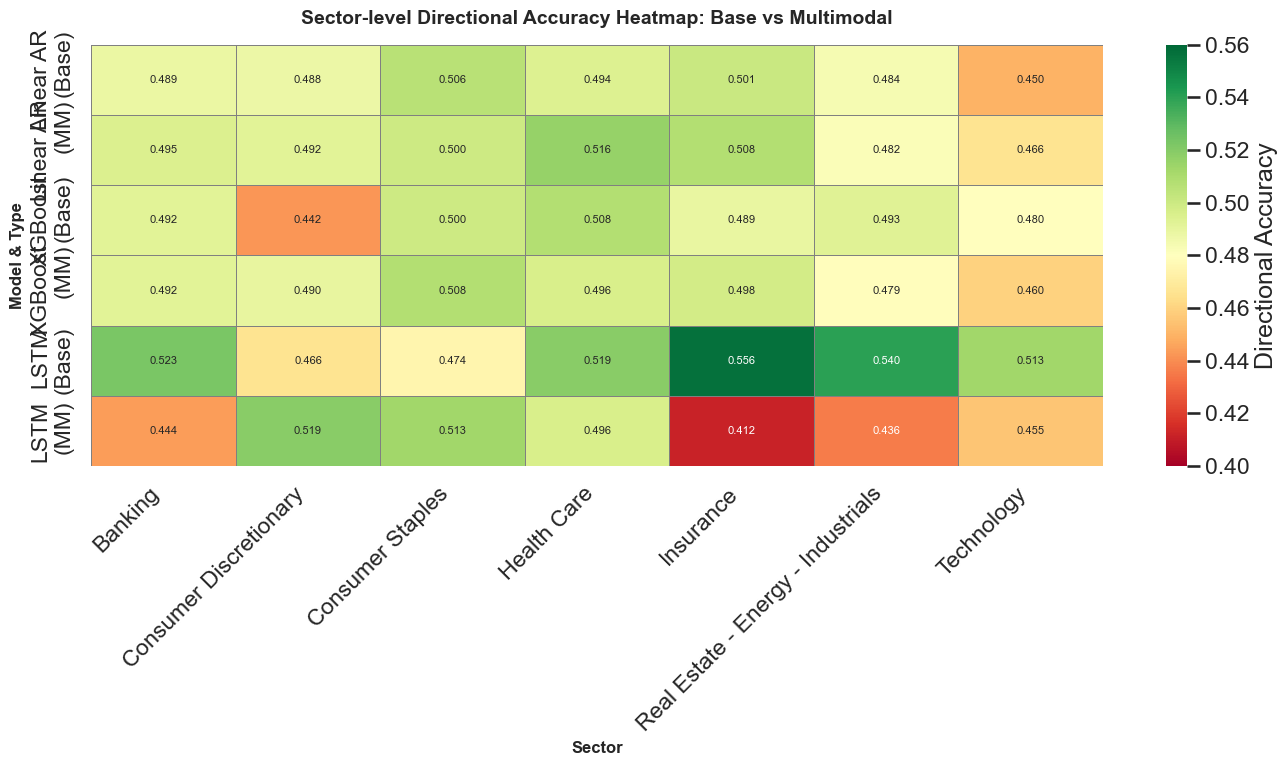

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\4_heatmap_sector_level_diracc.png

Sector-level heatmaps saved to: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures


In [15]:
# Sector-level Heatmaps - showing all sectors across all models

# Get all sectors that appear in any model
all_sectors_list = sorted(list(set(sector_df["Sector"].unique())))

# ============================================
# Sector-level RMSE Heatmap
# ============================================
heatmap_data_sector_rmse = []
heatmap_labels_sector = []

for model in models:
    model_data = sector_df[sector_df["Model"] == model]
    base_row = []
    mm_row = []
    for sector in all_sectors_list:
        sector_data = model_data[model_data["Sector"] == sector]
        if len(sector_data) > 0:
            base_row.append(sector_data["RMSE_base"].values[0])
            mm_row.append(sector_data["RMSE_mm"].values[0])
        else:
            base_row.append(np.nan)
            mm_row.append(np.nan)
    
    heatmap_data_sector_rmse.append(base_row)
    heatmap_data_sector_rmse.append(mm_row)
    heatmap_labels_sector.append(f"{model}\n(Base)")
    heatmap_labels_sector.append(f"{model}\n(MM)")

heatmap_df_sector_rmse = pd.DataFrame(heatmap_data_sector_rmse, index=heatmap_labels_sector, columns=all_sectors_list)

fig_heat_sector1, ax_heat_sector1 = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_df_sector_rmse, annot=True, fmt=".4f", cmap="YlOrRd", 
            cbar_kws={"label": "RMSE"}, ax=ax_heat_sector1, linewidths=0.5, linecolor="gray",
            annot_kws={"fontsize": 8})
ax_heat_sector1.set_title("Sector-level RMSE Heatmap: Base vs Multimodal", fontsize=14, weight="bold", pad=15)
ax_heat_sector1.set_xlabel("Sector", fontsize=12, weight="bold")
ax_heat_sector1.set_ylabel("Model & Type", fontsize=12, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "3_heatmap_sector_level_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '3_heatmap_sector_level_rmse.png'}")

# ============================================
# Sector-level Directional Accuracy Heatmap
# ============================================
heatmap_data_sector_diracc = []

for model in models:
    model_data = sector_df[sector_df["Model"] == model]
    base_row = []
    mm_row = []
    for sector in all_sectors_list:
        sector_data = model_data[model_data["Sector"] == sector]
        if len(sector_data) > 0:
            base_row.append(sector_data["DirAcc_base"].values[0])
            mm_row.append(sector_data["DirAcc_mm"].values[0])
        else:
            base_row.append(np.nan)
            mm_row.append(np.nan)
    
    heatmap_data_sector_diracc.append(base_row)
    heatmap_data_sector_diracc.append(mm_row)

heatmap_df_sector_diracc = pd.DataFrame(heatmap_data_sector_diracc, index=heatmap_labels_sector, columns=all_sectors_list)

fig_heat_sector2, ax_heat_sector2 = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_df_sector_diracc, annot=True, fmt=".3f", cmap="RdYlGn", 
            cbar_kws={"label": "Directional Accuracy"}, ax=ax_heat_sector2, 
            linewidths=0.5, linecolor="gray", vmin=0.40, vmax=0.56,
            annot_kws={"fontsize": 8})
ax_heat_sector2.set_title("Sector-level Directional Accuracy Heatmap: Base vs Multimodal", fontsize=14, weight="bold", pad=15)
ax_heat_sector2.set_xlabel("Sector", fontsize=12, weight="bold")
ax_heat_sector2.set_ylabel("Model & Type", fontsize=12, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "4_heatmap_sector_level_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '4_heatmap_sector_level_diracc.png'}")

print(f"\nSector-level heatmaps saved to: {figures_dir}")


### Sector-level Heatmap: Top Sectors Only (Cleaner View)


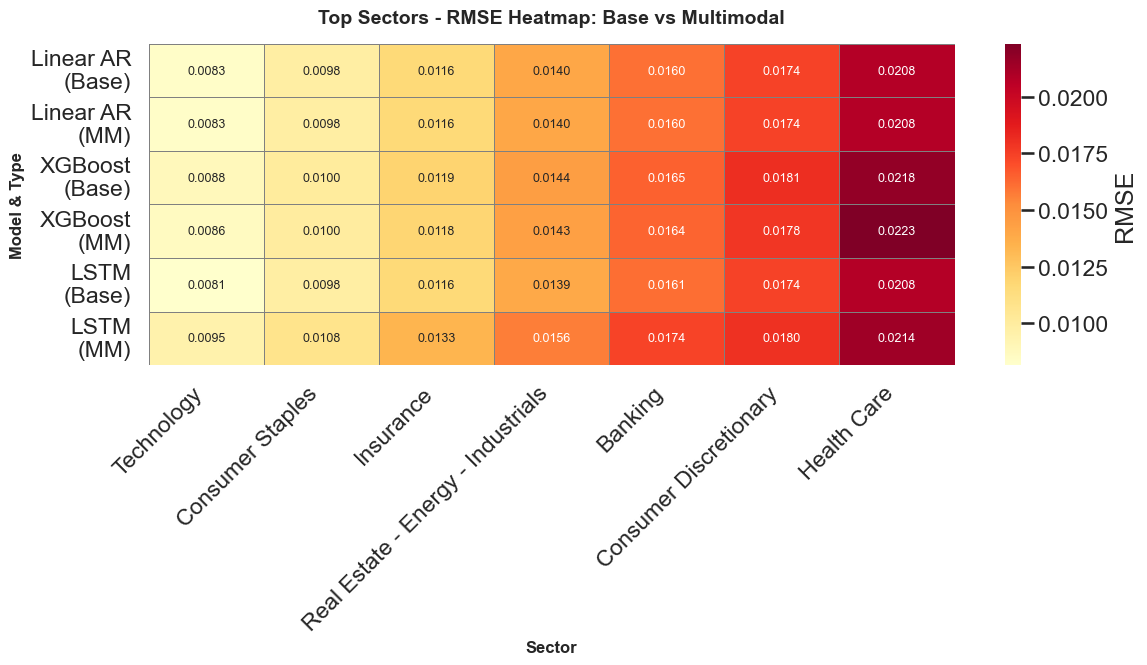

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\3_heatmap_top_sectors_rmse.png


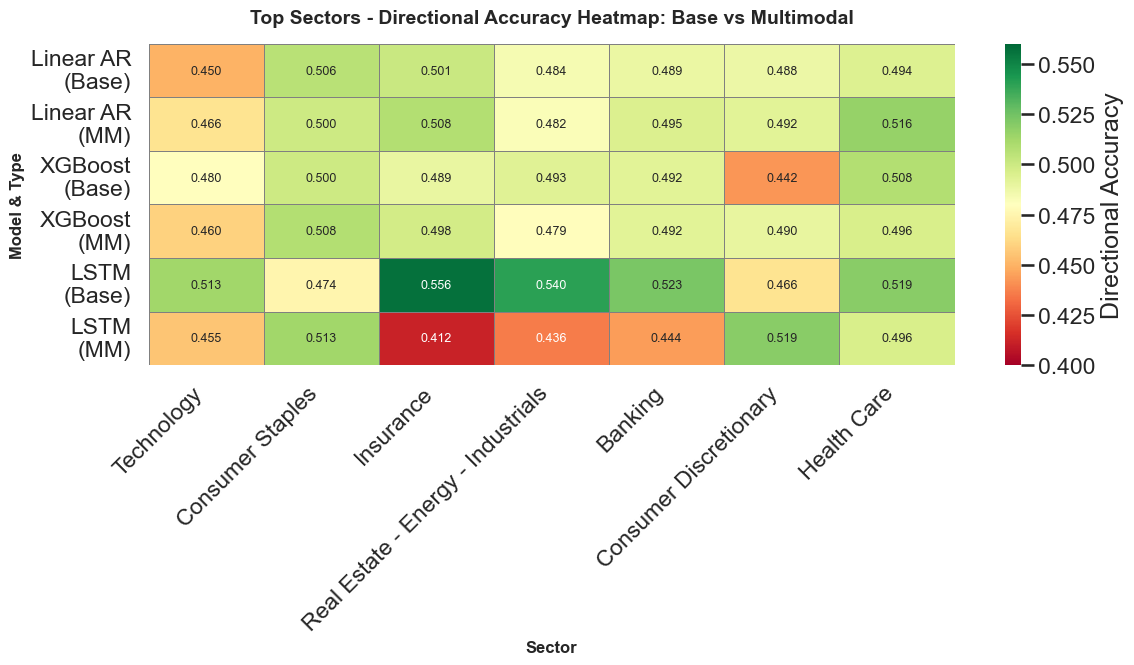

Saved: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures\4_heatmap_top_sectors_diracc.png

Top sectors heatmaps saved to: C:\Users\mkcak\OneDrive - Hochschule Luzern\Modules\master_thesis\multimodal-finance-forecasting\figures


In [16]:
# Create heatmaps for top sectors only (the ones we used in the bar charts)
# This gives a cleaner view focusing on the most relevant sectors

# Use the same top_sector_names from earlier (if defined, otherwise recalculate)
if 'top_sector_names' not in locals():
    # Recalculate top sectors
    all_sectors = set()
    for model in sector_data.keys():
        all_sectors.update(sector_data[model].keys())
    
    sector_avg_rmse = {}
    for sector in all_sectors:
        rmses = []
        for model in sector_data.keys():
            if sector in sector_data[model]:
                rmses.append(sector_data[model][sector]["RMSE_mm"])
        if rmses:
            sector_avg_rmse[sector] = np.mean(rmses)
    
    top_sectors = sorted(sector_avg_rmse.items(), key=lambda x: x[1])[:7]
    top_sector_names = [s[0] for s in top_sectors]

# ============================================
# Top Sectors RMSE Heatmap
# ============================================
heatmap_data_top_rmse = []
heatmap_labels_top = []

for model in models:
    model_data = sector_df[sector_df["Model"] == model]
    base_row = []
    mm_row = []
    for sector in top_sector_names:
        sector_data_model = model_data[model_data["Sector"] == sector]
        if len(sector_data_model) > 0:
            base_row.append(sector_data_model["RMSE_base"].values[0])
            mm_row.append(sector_data_model["RMSE_mm"].values[0])
        else:
            base_row.append(np.nan)
            mm_row.append(np.nan)
    
    heatmap_data_top_rmse.append(base_row)
    heatmap_data_top_rmse.append(mm_row)
    heatmap_labels_top.append(f"{model}\n(Base)")
    heatmap_labels_top.append(f"{model}\n(MM)")

heatmap_df_top_rmse = pd.DataFrame(heatmap_data_top_rmse, index=heatmap_labels_top, columns=top_sector_names)

fig_heat_top1, ax_heat_top1 = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_df_top_rmse, annot=True, fmt=".4f", cmap="YlOrRd", 
            cbar_kws={"label": "RMSE"}, ax=ax_heat_top1, linewidths=0.5, linecolor="gray",
            annot_kws={"fontsize": 9})
ax_heat_top1.set_title("Top Sectors - RMSE Heatmap: Base vs Multimodal", fontsize=14, weight="bold", pad=15)
ax_heat_top1.set_xlabel("Sector", fontsize=12, weight="bold")
ax_heat_top1.set_ylabel("Model & Type", fontsize=12, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "3_heatmap_top_sectors_rmse.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '3_heatmap_top_sectors_rmse.png'}")

# ============================================
# Top Sectors Directional Accuracy Heatmap
# ============================================
heatmap_data_top_diracc = []

for model in models:
    model_data = sector_df[sector_df["Model"] == model]
    base_row = []
    mm_row = []
    for sector in top_sector_names:
        sector_data_model = model_data[model_data["Sector"] == sector]
        if len(sector_data_model) > 0:
            base_row.append(sector_data_model["DirAcc_base"].values[0])
            mm_row.append(sector_data_model["DirAcc_mm"].values[0])
        else:
            base_row.append(np.nan)
            mm_row.append(np.nan)
    
    heatmap_data_top_diracc.append(base_row)
    heatmap_data_top_diracc.append(mm_row)

heatmap_df_top_diracc = pd.DataFrame(heatmap_data_top_diracc, index=heatmap_labels_top, columns=top_sector_names)

fig_heat_top2, ax_heat_top2 = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_df_top_diracc, annot=True, fmt=".3f", cmap="RdYlGn", 
            cbar_kws={"label": "Directional Accuracy"}, ax=ax_heat_top2, 
            linewidths=0.5, linecolor="gray", vmin=0.40, vmax=0.56,
            annot_kws={"fontsize": 9})
ax_heat_top2.set_title("Top Sectors - Directional Accuracy Heatmap: Base vs Multimodal", fontsize=14, weight="bold", pad=15)
ax_heat_top2.set_xlabel("Sector", fontsize=12, weight="bold")
ax_heat_top2.set_ylabel("Model & Type", fontsize=12, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "4_heatmap_top_sectors_diracc.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / '4_heatmap_top_sectors_diracc.png'}")

print(f"\nTop sectors heatmaps saved to: {figures_dir}")
